In [78]:
import numpy as np
import pandas as pd

In [79]:
import seaborn as sns

# Load dataset
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [80]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['species'] = label.fit_transform(df['species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [81]:
df = df[df['species'] !=0][['sepal_width','petal_length','species']]
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


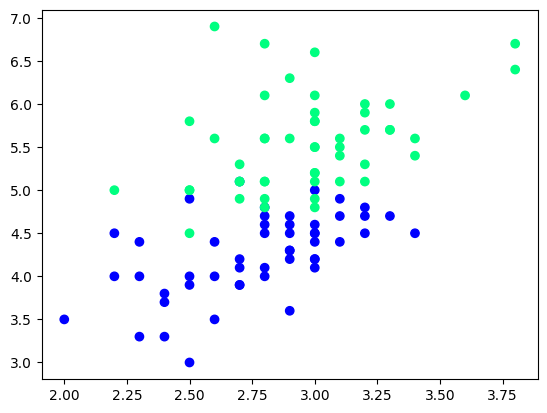

In [82]:
import matplotlib.pyplot as plt
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [83]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:100,:].sample(5)
df_train

,sepal_width,petal_length,species
65,3.1,4.4,1
84,3.0,4.5,1
60,2.0,3.5,1
95,3.0,4.2,1
50,3.2,4.7,1
90,2.6,4.4,1
86,3.1,4.7,1
105,3.0,6.6,2
55,2.8,4.5,1
77,3.0,5.0,1


In [84]:
df_val

,sepal_width,petal_length,species
108,2.5,5.8,2
104,3.0,5.8,2
134,2.6,5.6,2
102,3.0,5.9,2
141,3.1,5.1,2


In [85]:
df_test

,sepal_width,petal_length,species
79,2.6,3.5,1
91,3.0,4.6,1
113,2.5,5.0,2
122,2.8,6.7,2
147,3.0,5.2,2


In [86]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values
y_test

array([2, 2, 2, 2, 2])

## Case 1 - Bagging

In [87]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [88]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values,y.values,clf=clf,legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

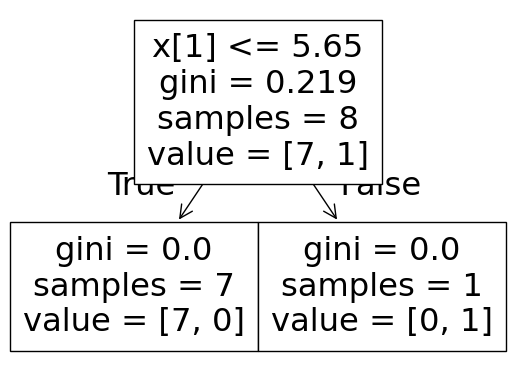

c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


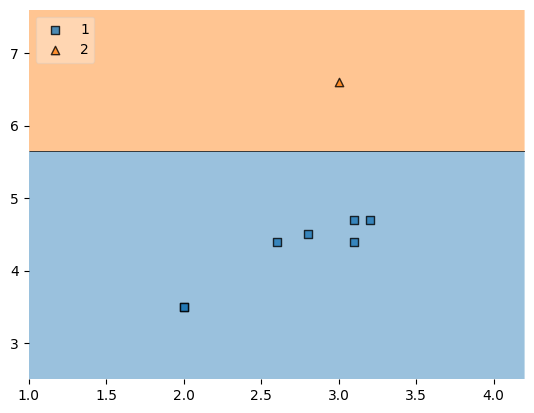

In [89]:
# Data for tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1,X,y)



In [90]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
90,2.6,4.4,1
65,3.1,4.4,1
95,3.0,4.2,1
50,3.2,4.7,1
65,3.1,4.4,1
50,3.2,4.7,1
86,3.1,4.7,1
50,3.2,4.7,1


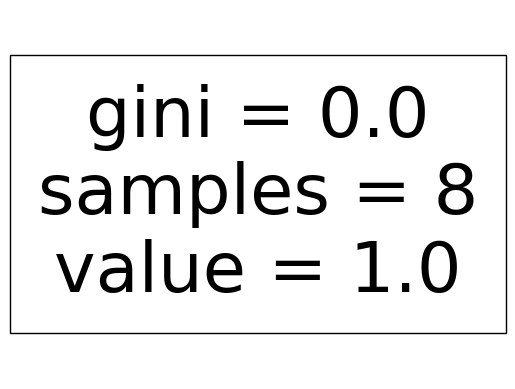

0.0


c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


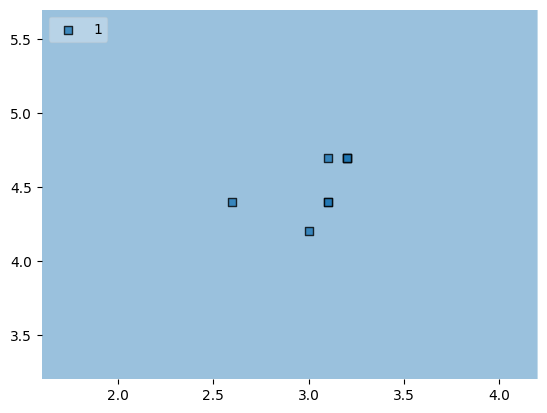

In [91]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [92]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
86,3.1,4.7,1
84,3.0,4.5,1
50,3.2,4.7,1
86,3.1,4.7,1
65,3.1,4.4,1
84,3.0,4.5,1
105,3.0,6.6,2
90,2.6,4.4,1


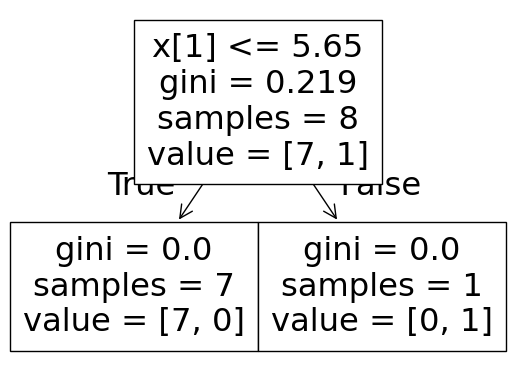

c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


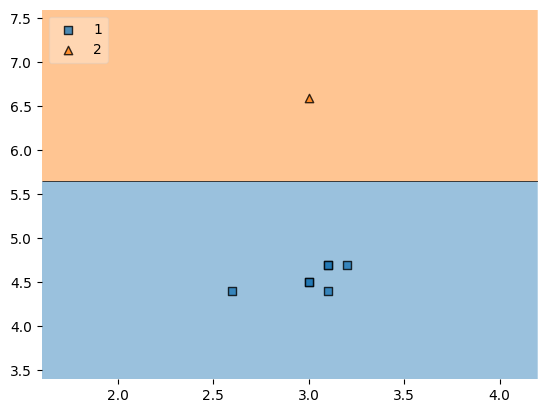

In [93]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

### Predict

In [94]:
df_test

,sepal_width,petal_length,species
79,2.6,3.5,1
91,3.0,4.6,1
113,2.5,5.0,2
122,2.8,6.7,2
147,3.0,5.2,2


In [95]:
print("Prdictor 1",dt_bag1.predict(np.array([2.5,5.8]).reshape(1,2)))
print("Prdictor 2",dt_bag2.predict(np.array([2.5,5.8]).reshape(1,2)))
print("Prdictor 3",dt_bag3.predict(np.array([2.5,5.8]).reshape(1,2)))

Prdictor 1 [2]
Prdictor 2 [1]
Prdictor 3 [2]


c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting

In [96]:
df_train

,sepal_width,petal_length,species
65,3.1,4.4,1
84,3.0,4.5,1
60,2.0,3.5,1
95,3.0,4.2,1
50,3.2,4.7,1
90,2.6,4.4,1
86,3.1,4.7,1
105,3.0,6.6,2
55,2.8,4.5,1
77,3.0,5.0,1


In [97]:
df.sample(8)

,sepal_width,petal_length,species
66,3.0,4.5,1
90,2.6,4.4,1
82,2.7,3.9,1
125,3.2,6.0,2
91,3.0,4.6,1
114,2.8,5.1,2
81,2.4,3.7,1
104,3.0,5.8,2


## Random subspace

In [102]:
df1 = sns.load_dataset('iris')
df1 = df1.sample(5)
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
37,4.9,3.6,1.4,0.1,setosa
98,5.1,2.5,3.0,1.1,versicolor
53,5.5,2.3,4.0,1.3,versicolor
131,7.9,3.8,6.4,2.0,virginica
78,6.0,2.9,4.5,1.5,versicolor


In [103]:
df1.sample(2,replace=True,axis=1)

,sepal_length,sepal_width
37,4.9,3.6
98,5.1,2.5
53,5.5,2.3
131,7.9,3.8
78,6.0,2.9


## Random Patches

In [104]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
37,4.9,3.6,1.4,0.1,setosa
98,5.1,2.5,3.0,1.1,versicolor
53,5.5,2.3,4.0,1.3,versicolor
131,7.9,3.8,6.4,2.0,virginica
78,6.0,2.9,4.5,1.5,versicolor


In [107]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal_width,petal_width
98,2.5,1.1
53,2.3,1.3
78,2.9,1.5
78,2.9,1.5
37,3.6,0.1
37,3.6,0.1
53,2.3,1.3
98,2.5,1.1
